In [19]:
# ==========================================
# Блок 2.3.1. Импорты, seed и устройство
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import random

# 1. Фиксация seed для воспроизводимости
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
# Обеспечиваем детерминизм алгоритмов CuDNN (может немного замедлить работу)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 2. Определение устройства (GPU при наличии, иначе CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используется устройство: {device}')

Используется устройство: cpu


In [20]:
# ==========================================
# Блок 2.3.2. Данные и DataLoader
# ==========================================

from torch.utils.data import DataLoader, random_split
from torchvision.datasets import KMNIST
import torchvision.transforms as transforms

# 1. Определение трансформаций
# Для KMNIST (и EMNIST) нормализация полезна для стабильности обучения.
# Среднее и стандартное отклонение для KMNIST: 0.1918, 0.3483
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1918,), (0.3483,))
])

# 2. Загрузка датасета
train_dataset_full = KMNIST(root='./data', train=True, download=False, transform=transform)
test_dataset = KMNIST(root='./data', train=False, download=False, transform=transform)

# 3. Разделение train на train и validation (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED) # Фиксируем seed для разбиения
)

# 4. Создание DataLoader
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер тренировочной выборки: {len(train_dataset)}")
print(f"Размер валидационной выборки: {len(val_dataset)}")
print(f"Размер тестовой выборки: {len(test_dataset)}")

# 5. Sanity-check
data_iter = iter(train_loader)
images, labels = next(data_iter)

print("\nSanity-check:")
print(f"Shape батча картинок (x.shape): {images.shape}") # [64, 1, 28, 28]
print(f"Shape батча меток (y.shape): {labels.shape}")     # [64]
print(f"Диапазон значений пикселей: min={images.min():.4f}, max={images.max():.4f}")
print(f"Количество классов: {len(train_dataset_full.classes)}")

Размер тренировочной выборки: 48000
Размер валидационной выборки: 12000
Размер тестовой выборки: 10000

Sanity-check:
Shape батча картинок (x.shape): torch.Size([64, 1, 28, 28])
Shape батча меток (y.shape): torch.Size([64])
Диапазон значений пикселей: min=-0.5507, max=2.3204
Количество классов: 10


In [21]:
# ==========================================
# Блок 2.3.3. Модель MLP и цикл обучения
# ==========================================

# 1. Определение архитектуры модели
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim1=128, hidden_dim2=64, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, num_classes)
            # CrossEntropyLoss принимает логиты, softmax не нужен
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

# Инициализация модели
model = MLP().to(device)
print(model)

# 2. Loss и Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 3. Функции цикла обучения и валидации
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Режим обучения (включает Dropout/BatchNorm)
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, dataloader, criterion, device):
    model.eval() # Режим оценки (отключает Dropout/BatchNorm)
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad(): # Отключаем расчет градиентов для валидации
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [22]:
# ==========================================
# Блок Инструменты для экспериментов (Часть A)
# ==========================================
import pandas as pd
import os
import copy

# 1. Функция для логирования результатов в CSV (строго по ТЗ)
def log_experiment(results_path, experiment_id, config, history):
    os.makedirs(os.path.dirname(results_path), exist_ok=True)
    
    # Формируем строку таблицы строго по требуемым полям ТЗ
    record = {
        'experiment_id': experiment_id,
        'dataset': config.get('dataset', 'KMNIST'),
        'seed': config.get('seed', 42),
        'model_summary': config.get('model_summary', '256-128-64'),
        'optimizer': config.get('optimizer', 'Adam'),
        'lr': config.get('lr', 1e-3),
        'momentum': config.get('momentum', 0), # 0 для Adam
        'weight_decay': config.get('weight_decay', 0),
        'epochs_trained': len(history['train_loss']),
        'best_val_accuracy': max(history['val_acc']),
        'best_val_loss': min(history['val_loss'])
    }
    
    df = pd.DataFrame([record])
    
    if not os.path.exists(results_path):
        df.to_csv(results_path, index=False)
    else:
        df.to_csv(results_path, mode='a', header=False, index=False)
    print(f"✅ Эксперимент {experiment_id} залогирован.")

# 2. Класс EarlyStopping
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
        if self.mode == 'max':
            self.val_func = lambda val, best: val > best + self.min_delta
        else:
            self.val_func = lambda val, best: val < best - self.min_delta

    def __call__(self, val_metric, model):
        if self.best_score is None:
            self.best_score = val_metric
            self.save_checkpoint(model)
        elif self.val_func(val_metric, self.best_score):
            self.best_score = val_metric
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                print(f"🛑 Early stopping: остановка обучения.")

    def save_checkpoint(self, model):
        self.best_model_state = copy.deepcopy(model.state_dict())

# 3. Универсальная функция обучения (для всех экспериментов)
def run_training(model, train_loader, val_loader, criterion, optimizer, device, epochs=20, early_stopping=None):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        
        if early_stopping:
            early_stopping(val_acc, model)
            if early_stopping.early_stop:
                model.load_state_dict(early_stopping.best_model_state)
                break
                
    return history

In [23]:
# 1. Архитектура для экспериментов (Base, Dropout, BatchNorm)
class ExperimentalMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[256, 128, 64], num_classes=10, dropout_p=0.0, use_bn=False):
        super(ExperimentalMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        curr_dim = input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(curr_dim, h_dim))
            
            # Добавляем BatchNorm, если нужно (между Linear и ReLU)
            if use_bn:
                layers.append(nn.BatchNorm1d(h_dim))
                
            layers.append(nn.ReLU())
            
            # Добавляем Dropout, если нужно
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            
            curr_dim = h_dim
            
        # Выходной слой
        layers.append(nn.Linear(curr_dim, num_classes))
        
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits


# Путь к файлу результатов
results_path = './artifacts/runs.csv'

# Одинаковая конфигурация для всех экспериментов
# Одинаковая конфигурация для всех экспериментов
base_config = {
    'hidden_dims': [256, 128, 64],
    'model_summary': '256-128-64 / ReLU',
    'lr': 1e-3,
    'batch_size': 64,
    'epochs': 15,
    'optimizer': 'Adam',
    'dataset': 'KMNIST',
    'seed': 42
}

# --- Эксперимент E1: Base ---
print("\n🚀 Запуск E1: Base")
model_e1 = ExperimentalMLP(hidden_dims=base_config['hidden_dims']).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=base_config['lr'])
history_e1 = run_training(model_e1, train_loader, val_loader, criterion, optimizer_e1, device, epochs=base_config['epochs'])
log_experiment(results_path, 'E1_Base', base_config, history_e1)

# --- Эксперимент E2: Dropout ---
print("\n🚀 Запуск E2: Dropout")
dropout_p = 0.3
config_e2 = base_config.copy()
config_e2['dropout_p'] = dropout_p
model_e2 = ExperimentalMLP(hidden_dims=config_e2['hidden_dims'], dropout_p=dropout_p).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=config_e2['lr'])
history_e2 = run_training(model_e2, train_loader, val_loader, criterion, optimizer_e2, device, epochs=config_e2['epochs'])
log_experiment(results_path, 'E2_Dropout', config_e2, history_e2)

# --- Эксперимент E3: BatchNorm ---
print("\n🚀 Запуск E3: BatchNorm")
config_e3 = base_config.copy()
config_e3['use_bn'] = True
model_e3 = ExperimentalMLP(hidden_dims=config_e3['hidden_dims'], use_bn=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=config_e3['lr'])
history_e3 = run_training(model_e3, train_loader, val_loader, criterion, optimizer_e3, device, epochs=config_e3['epochs'])
log_experiment(results_path, 'E3_BatchNorm', config_e3, history_e3)

# ==========================================
# Эксперимент E4: EarlyStopping и сохранение лучшей модели
# ==========================================

# 1. Сравниваем E2 и E3 по лучшей точности на валидации (строго по ТЗ)
val_acc_e2 = max(history_e2['val_acc'])
val_acc_e3 = max(history_e3['val_acc'])

print(f"Результаты: E2 (Dropout) = {val_acc_e2:.4f}, E3 (BatchNorm) = {val_acc_e3:.4f}")

if val_acc_e2 > val_acc_e3:
    winner_name = "E2 (Dropout)"
    # Копируем параметры победителя
    best_params = {
        'hidden_dims': [256, 128, 64],
        'dropout_p': 0.3, # используем значение из твоего E2
        'use_bn': False
    }
    print(f"🏆 Выбран вариант: {winner_name}")
else:
    winner_name = "E3 (BatchNorm)"
    best_params = {
        'hidden_dims': [256, 128, 64],
        'dropout_p': 0.0,
        'use_bn': True # используем значение из твоего E3
    }
    print(f"🏆 Выбран вариант: {winner_name}")

# 2. Создаем модель на основе победителя
model_e4 = ExperimentalMLP(**best_params).to(device)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# 3. Инициализируем EarlyStopping
# patience=3 означает, что если лосс не падает 3 эпохи подряд, обучение прервется
early_stopper = EarlyStopping(patience=3, min_delta=0.001)

print(f"\n🚀 Запуск финального обучения E4 с EarlyStopping (до 50 эпох)...")

# 4. Обучение
history_e4 = run_training(
    model=model_e4,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_e4,
    device=device,
    epochs=50, 
    early_stopping=early_stopper
)

# 5. Логирование в csv (обязательно обнови функцию log_experiment, как я писал в первом сообщении)
e4_config = base_config.copy()
e4_config.update(best_params)
e4_config['model_summary'] = winner_name + " + EarlyStopping"
log_experiment(results_path, 'E4', e4_config, history_e4)

# 6. СОХРАНЕНИЕ АРТЕФАКТОВ (как требует ТЗ)
os.makedirs('./artifacts', exist_ok=True)

# Сохраняем веса модели
torch.save(model_e4.state_dict(), './artifacts/best_model.pt')

# Сохраняем финальный конфиг в JSON
import json
final_config_json = {
    'experiment_id': 'E4',
    'winner_architecture': winner_name,
    'hidden_dims': best_params['hidden_dims'],
    'dropout_p': best_params['dropout_p'],
    'use_bn': best_params['use_bn'],
    'best_val_acc': max(history_e4['val_acc']),
    'epochs_completed': len(history_e4['train_loss'])
}

with open('./artifacts/best_config.json', 'w') as f:
    json.dump(final_config_json, f, indent=4)

print("\n✅ Эксперимент E4 завершен.")
print(f"✅ Модель сохранена: artifacts/best_model.pt")
print(f"✅ Конфиг сохранен: artifacts/best_config.json")


🚀 Запуск E1: Base
Epoch 1/15 | Train Loss: 0.3024 | Train Acc: 0.9082 | Val Loss: 0.1688 | Val Acc: 0.9492
Epoch 2/15 | Train Loss: 0.1184 | Train Acc: 0.9629 | Val Loss: 0.1185 | Val Acc: 0.9651
Epoch 3/15 | Train Loss: 0.0831 | Train Acc: 0.9740 | Val Loss: 0.1064 | Val Acc: 0.9684
Epoch 4/15 | Train Loss: 0.0638 | Train Acc: 0.9795 | Val Loss: 0.1002 | Val Acc: 0.9699
Epoch 5/15 | Train Loss: 0.0549 | Train Acc: 0.9820 | Val Loss: 0.0866 | Val Acc: 0.9743
Epoch 6/15 | Train Loss: 0.0431 | Train Acc: 0.9860 | Val Loss: 0.1042 | Val Acc: 0.9731
Epoch 7/15 | Train Loss: 0.0375 | Train Acc: 0.9877 | Val Loss: 0.1012 | Val Acc: 0.9718
Epoch 8/15 | Train Loss: 0.0311 | Train Acc: 0.9898 | Val Loss: 0.0886 | Val Acc: 0.9760
Epoch 9/15 | Train Loss: 0.0282 | Train Acc: 0.9910 | Val Loss: 0.1041 | Val Acc: 0.9751
Epoch 10/15 | Train Loss: 0.0270 | Train Acc: 0.9910 | Val Loss: 0.1011 | Val Acc: 0.9758
Epoch 11/15 | Train Loss: 0.0236 | Train Acc: 0.9923 | Val Loss: 0.1198 | Val Acc: 0.9740


In [24]:
# ==========================================
# Блок Финальная оценка лучшей модели (Тест)
# ==========================================
print("\n🏁 Финальная оценка лучшей модели (E4) на тесте:")
test_loss, test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")


🏁 Финальная оценка лучшей модели (E4) на тесте:
Test Loss: 0.0701 | Test Acc: 0.9778


In [25]:
# ==========================================
# Блок Запуск экспериментов O1-O3 (Часть B)
# ==========================================

# Определяем архитектуру лучшего эксперимента (E4)
best_arch_dims = [256, 128, 64]
use_bn = True # Зависит от того, что выиграло в Части А
dropout_p = 0.3 # Зависит от того, что выиграло в Части А

# --- Эксперимент O1: LR слишком большой (Adam) ---
print("\n🚀 Запуск O1: LR слишком большой (Adam)")
lr_high = 1e-1
model_o1 = ExperimentalMLP(hidden_dims=best_arch_dims, dropout_p=dropout_p, use_bn=use_bn).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=lr_high)
history_o1 = run_training(model_o1, train_loader, val_loader, criterion, optimizer_o1, device, epochs=5)
log_experiment(results_path, 'O1_LR_High', {'lr': lr_high, 'optimizer': 'Adam'}, history_o1)

# --- Эксперимент O2: LR слишком маленький (Adam) ---
print("\n🚀 Запуск O2: LR слишком маленький (Adam)")
lr_low = 1e-5
model_o2 = ExperimentalMLP(hidden_dims=best_arch_dims, dropout_p=dropout_p, use_bn=use_bn).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=lr_low)
history_o2 = run_training(model_o2, train_loader, val_loader, criterion, optimizer_o2, device, epochs=5)
log_experiment(results_path, 'O2_LR_Low', {'lr': lr_low, 'optimizer': 'Adam'}, history_o2)

# --- Эксперимент O3: SGD + Momentum + Weight Decay ---
print("\n🚀 Запуск O3: SGD + Momentum + Weight Decay")
lr_sgd = 1e-2
momentum = 0.9
weight_decay = 1e-4
model_o3 = ExperimentalMLP(hidden_dims=best_arch_dims, dropout_p=dropout_p, use_bn=use_bn).to(device)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=lr_sgd, momentum=momentum, weight_decay=weight_decay)
history_o3 = run_training(model_o3, train_loader, val_loader, criterion, optimizer_o3, device, epochs=10)
log_experiment(results_path, 'O3_SGD_WD', 
               {'lr': lr_sgd, 'optimizer': 'SGD', 'momentum': momentum, 'weight_decay': weight_decay}, 
               history_o3)


🚀 Запуск O1: LR слишком большой (Adam)
Epoch 1/5 | Train Loss: 0.5918 | Train Acc: 0.8287 | Val Loss: 0.2417 | Val Acc: 0.9347
Epoch 2/5 | Train Loss: 0.4038 | Train Acc: 0.8908 | Val Loss: 0.2121 | Val Acc: 0.9463
Epoch 3/5 | Train Loss: 0.3523 | Train Acc: 0.9077 | Val Loss: 0.1599 | Val Acc: 0.9587
Epoch 4/5 | Train Loss: 0.3270 | Train Acc: 0.9132 | Val Loss: 0.1742 | Val Acc: 0.9557
Epoch 5/5 | Train Loss: 0.3053 | Train Acc: 0.9193 | Val Loss: 0.1589 | Val Acc: 0.9592
✅ Эксперимент O1_LR_High залогирован.

🚀 Запуск O2: LR слишком маленький (Adam)
Epoch 1/5 | Train Loss: 2.0585 | Train Acc: 0.3047 | Val Loss: 1.7101 | Val Acc: 0.6520
Epoch 2/5 | Train Loss: 1.6517 | Train Acc: 0.5702 | Val Loss: 1.3973 | Val Acc: 0.7669
Epoch 3/5 | Train Loss: 1.4039 | Train Acc: 0.6893 | Val Loss: 1.1823 | Val Acc: 0.8297
Epoch 4/5 | Train Loss: 1.2187 | Train Acc: 0.7608 | Val Loss: 1.0243 | Val Acc: 0.8608
Epoch 5/5 | Train Loss: 1.0719 | Train Acc: 0.8022 | Val Loss: 0.8771 | Val Acc: 0.8781


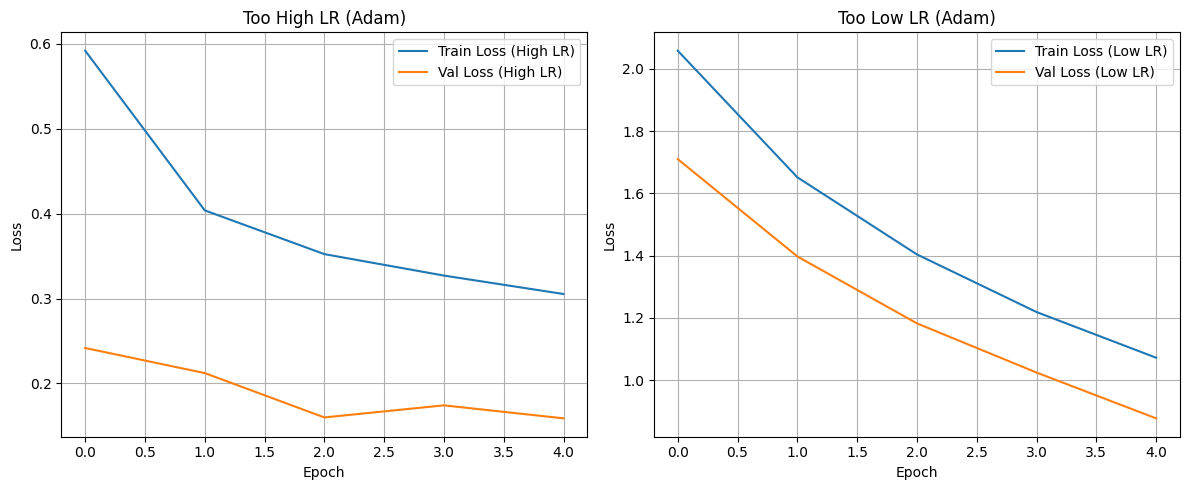

✅ График curves_lr_extremes.png сохранен.


In [26]:
# ==========================================
# Блок Визуализация O1 и O2
# ==========================================
def plot_lr_extremes(h1, h2):
    plt.figure(figsize=(12, 5))
    
    # Plotting Loss
    plt.subplot(1, 2, 1)
    plt.plot(h1['train_loss'], label='Train Loss (High LR)')
    plt.plot(h1['val_loss'], label='Val Loss (High LR)')
    plt.title('Too High LR (Adam)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(h2['train_loss'], label='Train Loss (Low LR)')
    plt.plot(h2['val_loss'], label='Val Loss (Low LR)')
    plt.title('Too Low LR (Adam)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    os.makedirs('./artifacts/figures', exist_ok=True)
    plt.savefig('./artifacts/figures/curves_lr_extremes.png')
    plt.show()

plot_lr_extremes(history_o1, history_o2)
print("✅ График curves_lr_extremes.png сохранен.")

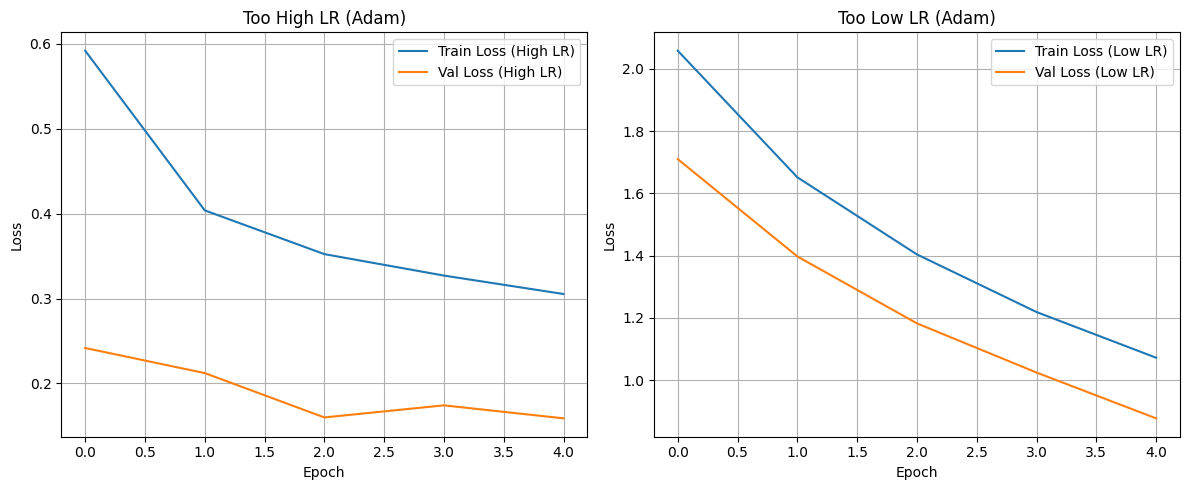

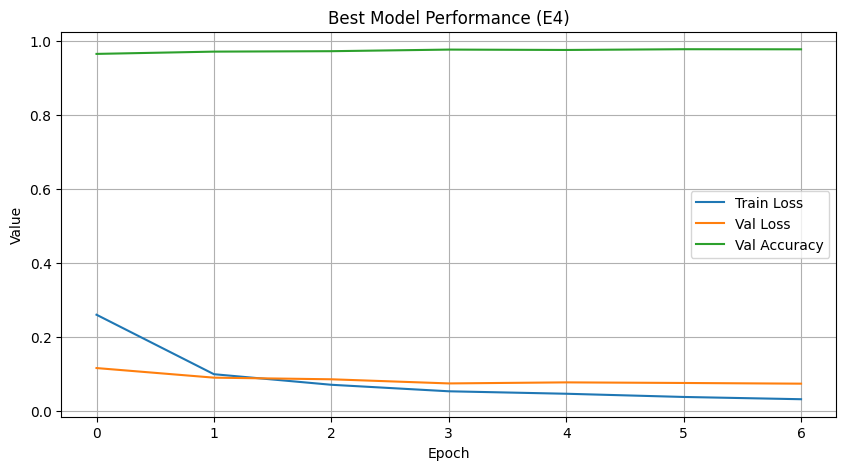

✅ График curves_best.png сохранен.
✅ Конфиг best_config.json сохранен.


In [27]:
# ==========================================
# Визуализация и сохранение артефактов
# ==========================================
import json

# 1. График плохих LR (O1, O2) - уже запустили, но сохраним явно
plot_lr_extremes(history_o1, history_o2)

# 2. График лучшего эксперимента (E4)
def plot_best_curves(history, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.title('Best Model Performance (E4)')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()

plot_best_curves(history_e4, './artifacts/figures/curves_best.png')
print("✅ График curves_best.png сохранен.")

# 3. JSON конфиг лучшей модели
best_config = {
    'model_arch': 'ExperimentalMLP(hidden_dims=[256, 128, 64], use_bn=True, dropout_p=0.3)',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': len(history_e4['train_loss']),
    'best_val_accuracy': max(history_e4['val_acc']),
    'early_stopping_patience': 3,
    'seed': 42
}

with open('./artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)
print("✅ Конфиг best_config.json сохранен.")